In [101]:
## TAREA TEMA2M2

###---Con la base de datos que vieron en el modulo1 y que se encuentra en Github en la carpeta de Modulo 2 llamada carpeta_q1_2026_final.parquet,
# ----calcular para cada uno de los ramos de accidentes personales y Gastos médicos:

# 1.	Calcular estadísticas descriptivas (número de pólizas, prima total, prima promedio, número de siniestros, siniestro promedio, etc.)
# 2.	Obtener los histogramas de las variables: sexo, edad, año de inicio de vigencia, plan, primas y siniestros. ¿Qué observas?
# 3.	Codifica las variables que consideres necesario. Explica por qué consideraste esas variables y que tipo de codificación aplicaste.
# 4.	Aplicar los 3 tipos de escalamiento a primas y siniestros. Obtén sus estadísticas y compáralas con las originales. ¿Qué concluyes?
# 5.	Haz la transformación Box-Cox, logarítmica y Yeo-Johnson al monto del siniestro. Haz un histograma de la serie original y cada una de las transformaciones. Agrega la distribución normal.
# 6.	Crea el Q-Q plot para la serie original y cada transformación, haz la prueba de hipótesis de normalidad. ¿Qué concluyes?
# 7.	Calcula las siguientes variables derivadas: mayor de 65 años, Siniestros altos (se definen como los montos pagados mayores a $25,000 en accidentes personales y mayores a $200,000 en gastos médicos). ¿Cuántos siniestros cumplen estas características y qué % del total de siniestros representan?
# 8.	Calcula la media del siniestro por sexo, año de inicio de vigencia y plan.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    LabelEncoder, OrdinalEncoder
)
from scipy.stats import boxcox, yeojohnson, shapiro
from sklearn.preprocessing import PowerTransformer
import scipy.stats as stats
from scipy.stats import normaltest


df_full= pd.read_parquet("cartera_q1_2026_final.parquet")


In [102]:
# Filtrar solo Accidentes Personales y GMM
ramos_interes = ['Accidentes Personales', 'GMM']
df = df_full[df_full['ramo'].isin(ramos_interes)].copy()
df = df.reset_index(drop=True)

print(f'Registros totales en el archivo : {len(df_full):,}')
print(f'Registros AP + GMM              : {len(df):,}')
print(f'\nDistribución por ramo:\n{df["ramo"].value_counts()}')


Registros totales en el archivo : 50,000
Registros AP + GMM              : 27,738

Distribución por ramo:
ramo
GMM                      22531
Accidentes Personales     5207
Autos                        0
Vida                         0
Name: count, dtype: int64


In [103]:
# PUNTO 1:

## Estadisticas descriptivas


def estadisticas_ramo(df, ramo):
    """Calcula estadísticas descriptivas clave para un ramo dado."""
    d = df[df['ramo'] == ramo]
    sin = d[d['n_siniestros'] > 0]  # solo pólizas con siniestro

    resumen = {
        'Número de pólizas'          : len(d),
        'Prima total ($)'            : d['prima_total'].sum(),
        'Prima promedio ($)'         : d['prima_total'].mean(),
        'Prima mediana ($)'          : d['prima_total'].median(),
        'Prima mín ($)'              : d['prima_total'].min(),
        'Prima máx ($)'              : d['prima_total'].max(),
        'Número de siniestros'       : d['n_siniestros'].sum(),
        'Pólizas con siniestro'      : len(sin),
        'Siniestro promedio ($)'     : sin['monto_pagado'].mean(),
        'Siniestro mediano ($)'      : sin['monto_pagado'].median(),
        'Siniestro mín ($)'          : sin['monto_pagado'].min(),
        'Siniestro máx ($)'          : sin['monto_pagado'].max(),
        'Monto total pagado ($)'     : d['monto_pagado'].sum(),
    }
    return pd.Series(resumen)

stats_ap  = estadisticas_ramo(df, 'Accidentes Personales')
stats_gmm = estadisticas_ramo(df, 'GMM')

resumen_df = pd.DataFrame({'Accidentes Personales': stats_ap, 'GMM': stats_gmm})

# Formato monetario para mostrar
pd.options.display.float_format = '{:,.2f}'.format
print('=' * 60)
print('ESTADÍSTICAS DESCRIPTIVAS POR RAMO')
print('=' * 60)
display(resumen_df)

ESTADÍSTICAS DESCRIPTIVAS POR RAMO


,Accidentes Personales,GMM
Número de pólizas,"5,207.00","22,531.00"
Prima total ($),"24,980,678.88","731,022,322.30"
Prima promedio ($),"4,797.52","32,445.18"
Prima mediana ($),"4,301.28","22,049.28"
Prima mín ($),"2,784.00","5,104.00"
Prima máx ($),"7,516.80","114,931.87"
Número de siniestros,"1,833.00","8,146.00"
Pólizas con siniestro,"1,541.00","6,845.00"
Siniestro promedio ($),"14,478.52","14,158.11"
Siniestro mediano ($),0.00,0.00


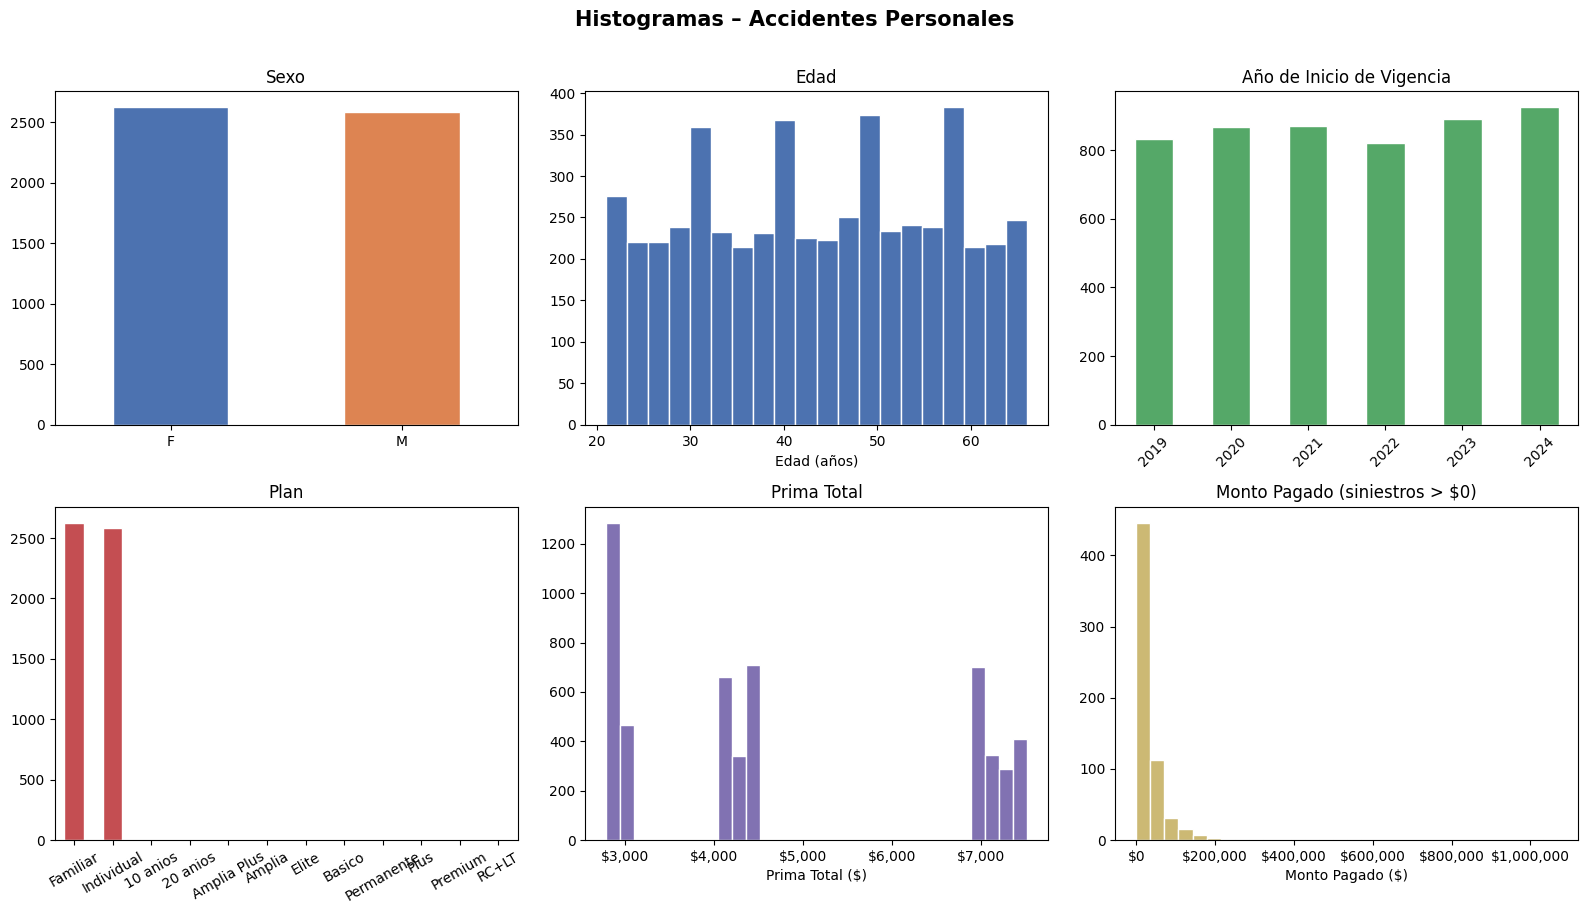

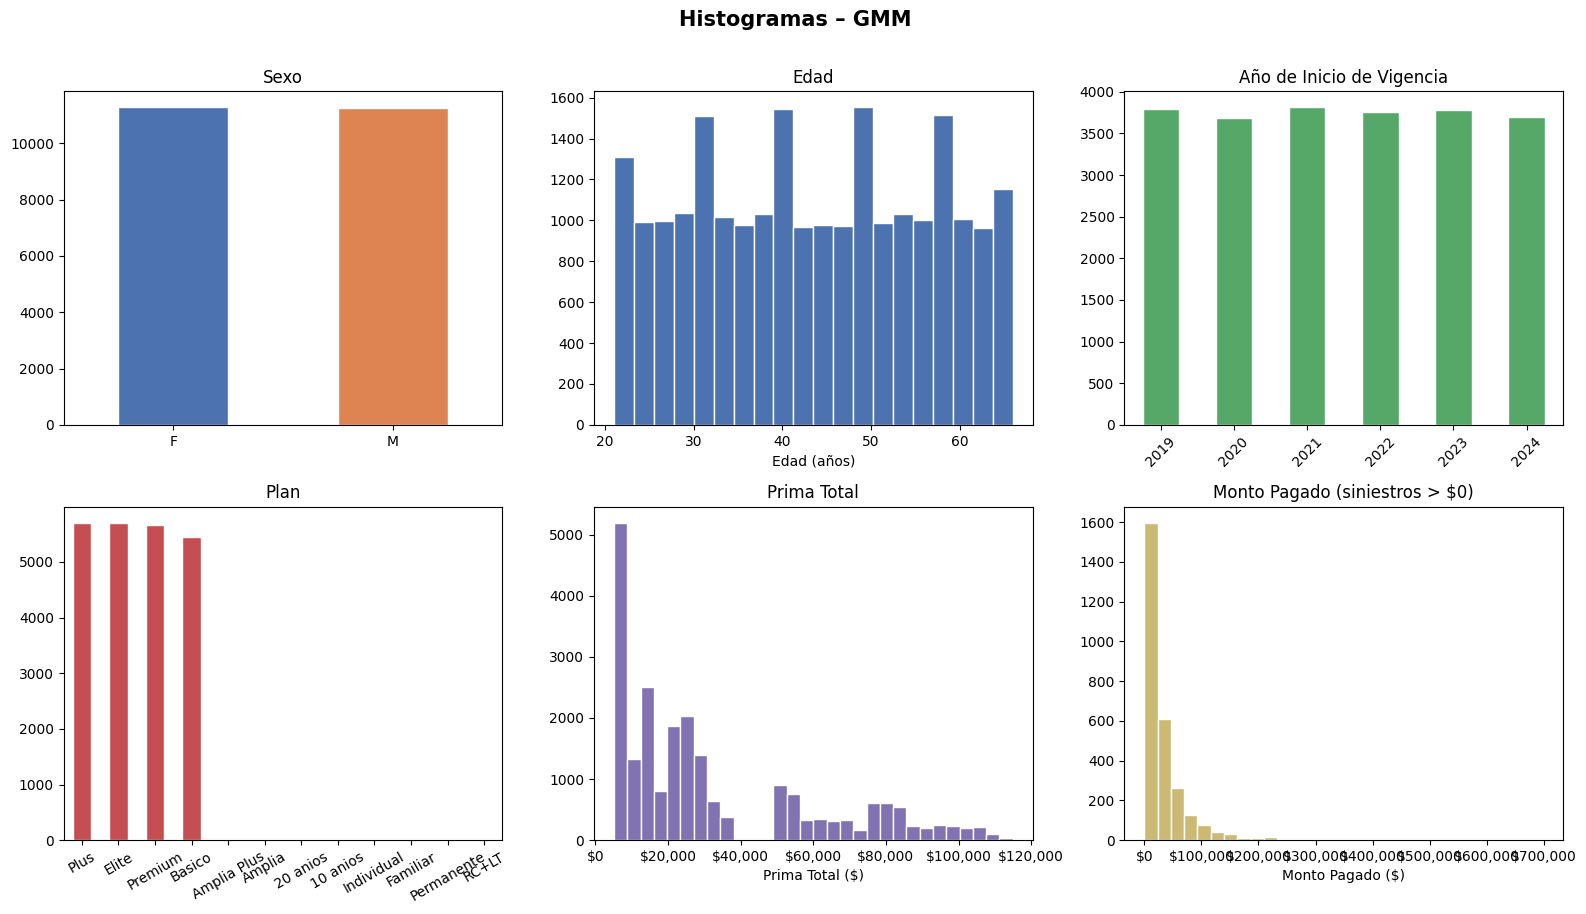


OBSERVACIONES:
- Sexo       : La distribución entre géneros puede ser desbalanceada según el ramo.
- Edad       : Distribución concentrada en adultos de 30 y cada aprox 10 años existe un incremento.
- Vigencia   : Mayor emisión en los ulitmos años de accidentes personales.
- Plan       : En Accidentes Personales hay más 'Individuales'; en GMM la distribución varía entre Básico/Plus/Premium/Elite.
- Prima      : La mayoría paga primas bajas, pocos pagan muy altas.
- Siniestros : Son muy pocos siniestros pero de montos altos.



In [104]:
# PUNTO 2:

## Histogramas

for ramo in ['Accidentes Personales', 'GMM']:
    d = df[df['ramo'] == ramo].copy()
    d['anio_inicio_vigencia'] = pd.to_datetime(d['fecha_inicio_vigencia']).dt.year

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f'Histogramas – {ramo}', fontsize=15, fontweight='bold', y=1.01)

    # Sexo
    d['sexo'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#4C72B0','#DD8452'], edgecolor='white')
    axes[0, 0].set_title('Sexo')
    axes[0, 0].set_xlabel('')
    axes[0, 0].tick_params(axis='x', rotation=0)

    # Edad
    axes[0, 1].hist(d['edad'].dropna(), bins=20, color='#4C72B0', edgecolor='white')
    axes[0, 1].set_title('Edad')
    axes[0, 1].set_xlabel('Edad (años)')

    # Año inicio vigencia
    d['anio_inicio_vigencia'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0, 2], color='#55A868', edgecolor='white')
    axes[0, 2].set_title('Año de Inicio de Vigencia')
    axes[0, 2].set_xlabel('')
    axes[0, 2].tick_params(axis='x', rotation=45)

    # Plan
    d['plan'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#C44E52', edgecolor='white')
    axes[1, 0].set_title('Plan')
    axes[1, 0].set_xlabel('')
    axes[1, 0].tick_params(axis='x', rotation=30)

    # Prima total
    axes[1, 1].hist(d['prima_total'].dropna(), bins=30, color='#8172B2', edgecolor='white')
    axes[1, 1].set_title('Prima Total')
    axes[1, 1].set_xlabel('Prima Total ($)')
    axes[1, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # Monto pagado (siniestros > 0)
    sin = d[d['monto_pagado'] > 0]['monto_pagado']
    axes[1, 2].hist(sin, bins=30, color='#CCB974', edgecolor='white')
    axes[1, 2].set_title('Monto Pagado (siniestros > $0)')
    axes[1, 2].set_xlabel('Monto Pagado ($)')
    axes[1, 2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    plt.tight_layout()
    plt.show()

print("""
OBSERVACIONES:
- Sexo       : La distribución entre géneros puede ser desbalanceada según el ramo.
- Edad       : Distribución concentrada en adultos de 30 y cada aprox 10 años existe un incremento.
- Vigencia   : Mayor emisión en los ulitmos años de accidentes personales.
- Plan       : En Accidentes Personales hay más 'Individuales'; en GMM la distribución varía entre Básico/Plus/Premium/Elite.
- Prima      : La mayoría paga primas bajas, pocos pagan muy altas.
- Siniestros : Son muy pocos siniestros pero de montos altos.
""")

In [105]:
# PUNTO 3

# Codificación

############ ONE HOT ENCODING

vars_ohe = [
    'sexo',
    'plan',
    'estado_civil',
    'canal_venta',
    'forma_pago',
    'tipo_vehiculo'
]

df_ohe = pd.get_dummies(df, columns=vars_ohe, drop_first=True)

print("One-Hot Encoding aplicado")
print("Columnas nuevas:", df_ohe.shape[1] - df.shape[1])
print("One-Hot Encoding se usó para variables nominales derivado que no presentan orden y evitar supuestos de jerarquía")

######## LABEL ENCODING ORDINARIO

# nivel de riesgo (IMPORTANTE: orden lógico)
map_riesgo = {
    'BAJO': 0,
    'MEDIO': 1,
    'ALTO': 2
}

df_ohe['nivel_riesgo_enc'] = df_ohe['nivel_riesgo'].map(map_riesgo)

# cuartil de prima
map_cuartil = {
    'Q1': 0,
    'Q2': 1,
    'Q3': 2,
    'Q4': 3
}

df_ohe['cuartil_prima_enc'] = df_ohe['cuartil_prima'].map(map_cuartil)

print("Label Encoding aplicado a variables ordinales debido a que presentan un orden natural y esto ayuda")

############ TARGET ENCODING

# Creamos variable de siniestralidad
df_ohe['tiene_siniestro'] = (df_ohe['n_siniestros'] > 0).astype(int)

# MUNICIPIO
target_mun = df_ohe.groupby('municipio')['tiene_siniestro'].mean()

df_ohe['municipio_te'] = df_ohe['municipio'].map(target_mun)

# OCUPACIÓN (si quieres incluirla)
target_ocup = df_ohe.groupby('ocupacion')['tiene_siniestro'].mean()

df_ohe['ocupacion_te'] = df_ohe['ocupacion'].map(target_ocup)

print("Target Encoding sustituye cada categoria por la proba de siniestro")



One-Hot Encoding aplicado
Columnas nuevas: 25
One-Hot Encoding se usó para variables nominales derivado que no presentan orden y evitar supuestos de jerarquía
Label Encoding aplicado a variables ordinales debido a que presentan un orden natural y esto ayuda
Target Encoding sustituye cada categoria por la proba de siniestro


C:\Users\aylin\AppData\Local\Temp\ipykernel_1016\2476399785.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_mun = df_ohe.groupby('municipio')['tiene_siniestro'].mean()
C:\Users\aylin\AppData\Local\Temp\ipykernel_1016\2476399785.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_ocup = df_ohe.groupby('ocupacion')['tiene_siniestro'].mean()



  RAMO: Accidentes Personales


,prima_total,prima_minmax,prima_std,prima_robust,monto_pagado,siniestro_minmax,siniestro_std,siniestro_robust
count,"5,207.00","5,207.00","5,207.00","5,207.00","5,207.00","5,207.00","5,207.00","5,207.00"
mean,"4,797.52",0.43,-0.00,0.13,"4,284.89",0.00,-0.00,"4,284.89"
std,"1,804.03",0.38,1.00,0.46,"25,761.29",0.02,1.00,"25,761.29"
min,"2,784.00",0.00,-1.12,-0.38,0.00,0.00,-0.17,0.00
25%,"3,006.72",0.05,-0.99,-0.33,0.00,0.00,-0.17,0.00
50%,"4,301.28",0.32,-0.28,0.00,0.00,0.00,-0.17,0.00
75%,"6,960.00",0.88,1.20,0.67,0.00,0.00,-0.17,0.00
max,"7,516.80",1.00,1.51,0.81,"1,067,933.83",1.00,41.29,"1,067,933.83"



  RAMO: GMM


,prima_total,prima_minmax,prima_std,prima_robust,monto_pagado,siniestro_minmax,siniestro_std,siniestro_robust
count,"22,531.00","22,531.00","22,531.00","22,531.00","22,531.00","22,531.00","22,531.00","22,531.00"
mean,"32,445.18",0.25,0.00,0.24,"4,301.29",0.01,-0.00,"4,301.29"
std,"28,387.43",0.26,1.00,0.66,"20,609.64",0.03,1.00,"20,609.64"
min,"5,104.00",0.00,-0.96,-0.39,0.00,0.00,-0.21,0.00
25%,"9,493.44",0.04,-0.81,-0.29,0.00,0.00,-0.21,0.00
50%,"22,049.28",0.15,-0.37,0.00,0.00,0.00,-0.21,0.00
75%,"52,571.20",0.43,0.71,0.71,0.00,0.00,-0.21,0.00
max,"114,931.87",1.00,2.91,2.16,"698,744.32",1.00,33.70,"698,744.32"


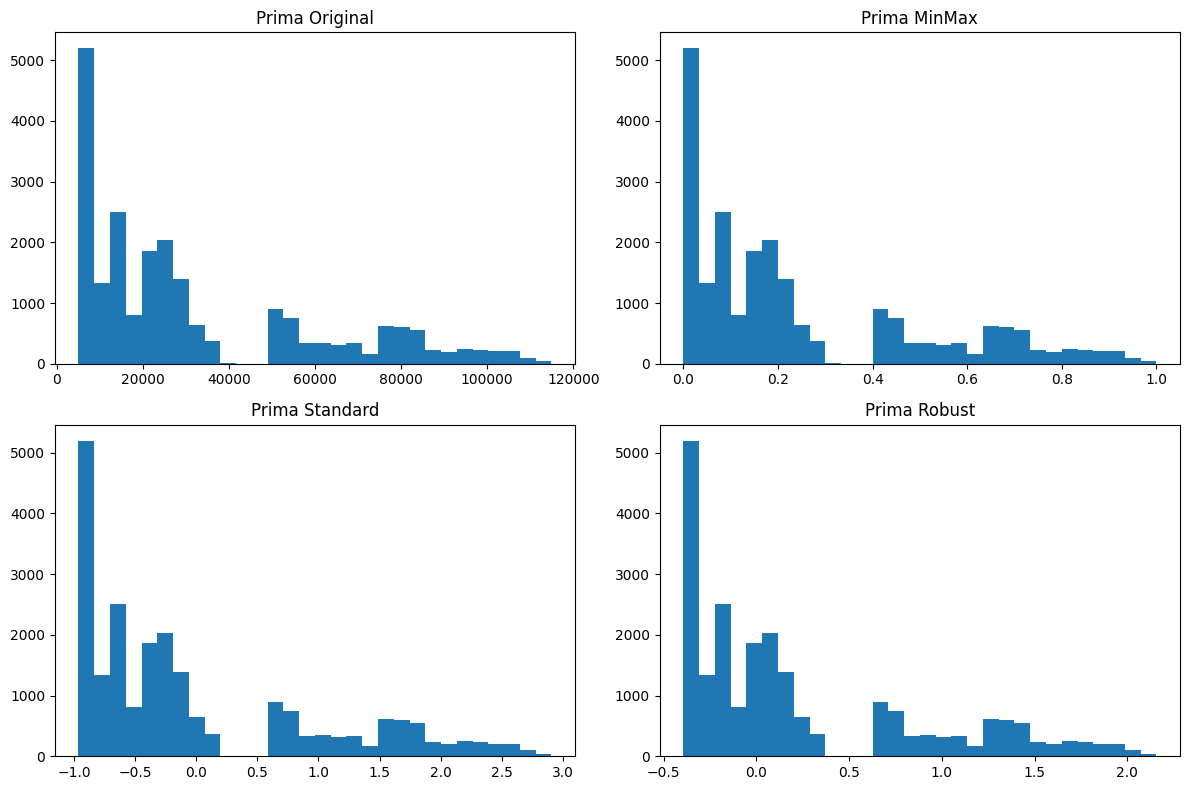


Valores mínimos y máximos después del escalamiento:
     prima_minmax  siniestro_minmax
min          0.00              0.00
max          1.00              1.00

─── CONCLUSIONES DEL ESCALAMIENTO ─────────────────────────────────────────────

Las estadísticas descriptivas de las versiones escaladas confirman que solo se
modifican las escalas de las variables, pero no cambia la forma general de su dsitribución.
El Robust es el más adecuado pq reserva mejor la forma de la distribución por el uso de la mediana.
──────────────────────────────────────────────────────────────────────────────



In [106]:
# PUNTO 4

# Escalamiento

for ramo in ['Accidentes Personales', 'GMM']:
    print(f'\n{"="*65}')
    print(f'  RAMO: {ramo}')
    print(f'{"="*65}')

    d = df[df['ramo'] == ramo][['prima_total', 'monto_pagado']].dropna().copy()

    # Escaladores
    minmax  = MinMaxScaler()
    std     = StandardScaler()
    robust  = RobustScaler()

    d_mm = pd.DataFrame(minmax.fit_transform(d),  columns=['prima_minmax',  'siniestro_minmax'])
    d_st = pd.DataFrame(std.fit_transform(d),     columns=['prima_std',     'siniestro_std'])
    d_ro = pd.DataFrame(robust.fit_transform(d),  columns=['prima_robust',  'siniestro_robust'])

    result = pd.concat([d.reset_index(drop=True), d_mm, d_st, d_ro], axis=1)

    cols = ['prima_total','prima_minmax','prima_std','prima_robust',
            'monto_pagado','siniestro_minmax','siniestro_std','siniestro_robust']
    display(result[cols].describe().round(4))
    
fig, axes = plt.subplots(2,2, figsize=(12,8))

axes[0,0].hist(result['prima_total'], bins=30)
axes[0,0].set_title('Prima Original')

axes[0,1].hist(result['prima_minmax'], bins=30)
axes[0,1].set_title('Prima MinMax')

axes[1,0].hist(result['prima_std'], bins=30)
axes[1,0].set_title('Prima Standard')

axes[1,1].hist(result['prima_robust'], bins=30)
axes[1,1].set_title('Prima Robust')

plt.tight_layout()
plt.show()

print("\nValores mínimos y máximos después del escalamiento:")
print(result[['prima_minmax','siniestro_minmax']].agg(['min','max']))

print("""
─── CONCLUSIONES DEL ESCALAMIENTO ─────────────────────────────────────────────

Las estadísticas descriptivas de las versiones escaladas confirman que solo se
modifican las escalas de las variables, pero no cambia la forma general de su dsitribución.
El Robust es el más adecuado pq reserva mejor la forma de la distribución por el uso de la mediana.
──────────────────────────────────────────────────────────────────────────────
""")


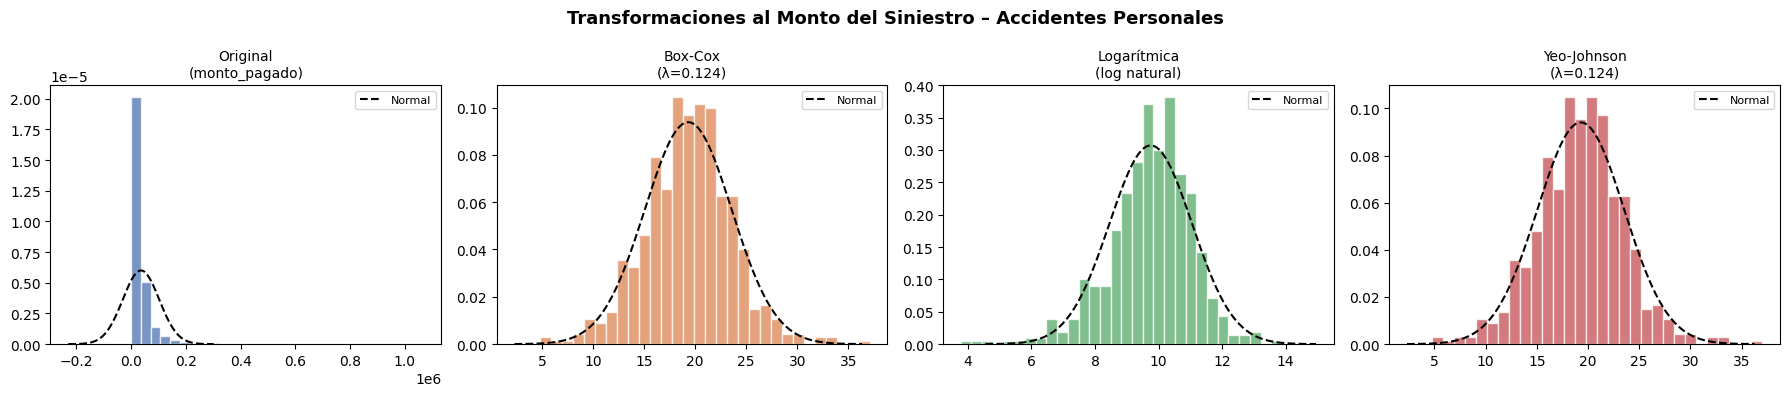

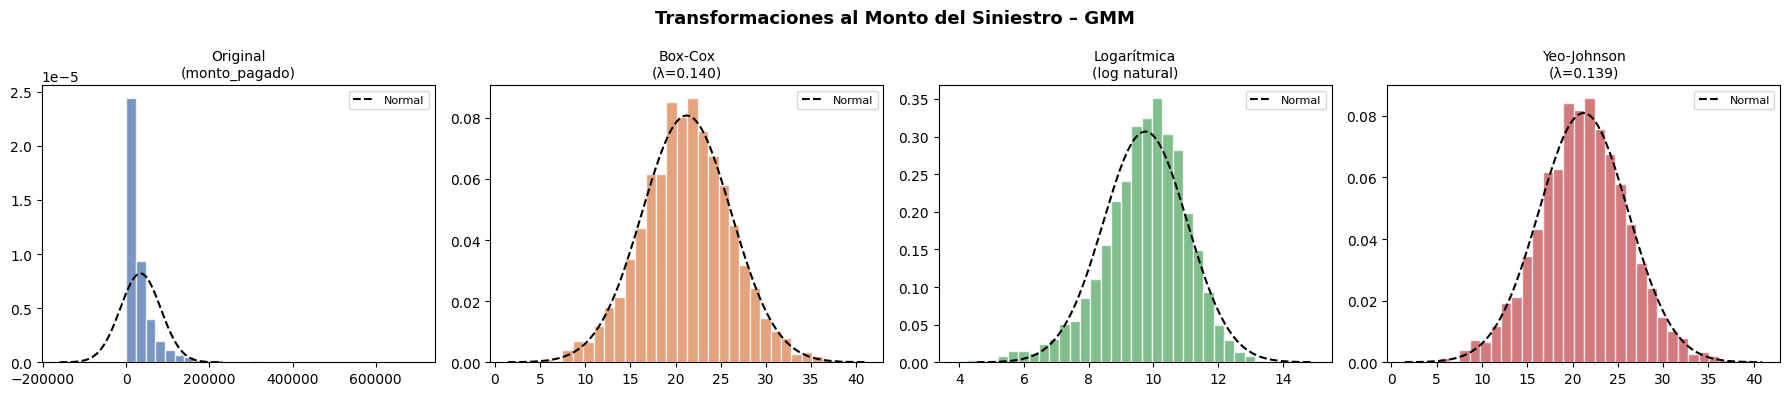


Visualmente se ve que Box-Cox y Yeo-Johnson presentan un mejor ajuste a la curva normal superpuesta en ambos ramo.



In [107]:
# PUNTO 5

# Transformaciones

for ramo in ['Accidentes Personales', 'GMM']:
    d = df[(df['ramo'] == ramo) & (df['monto_pagado'] > 0)]['monto_pagado'].dropna()

    # Transformaciones
    bc_data, lambda_bc = boxcox(d)
    log_data = np.log1p(d)
    yj_data, lambda_yj = yeojohnson(d)

    series = {
        f'Original\n(monto_pagado)': d.values,
        f'Box-Cox\n(λ={lambda_bc:.3f})': bc_data,
        f'Logarítmica\n(log natural)': log_data.values,
        f'Yeo-Johnson\n(λ={lambda_yj:.3f})': yj_data,
    }

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'Transformaciones al Monto del Siniestro – {ramo}',
                 fontsize=13, fontweight='bold')

    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    for ax, (titulo, vals), color in zip(axes, series.items(), colors):
        ax.hist(vals, bins=30, color=color, edgecolor='white', density=True, alpha=0.75)
        # Superponer curva normal
        mu, sigma = np.mean(vals), np.std(vals)
        x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
        ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', linewidth=1.5, label='Normal')
        ax.set_title(titulo, fontsize=10)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    
print("""
Visualmente se ve que Box-Cox y Yeo-Johnson presentan un mejor ajuste a la curva normal superpuesta en ambos ramo.
""")


  PRUEBA DE NORMALIDAD – Accidentes Personales
  (Shapiro-Wilk, muestra aleatoria n=500)
Transformación        Estadístico        p-valor  ¿Normal α=0.05?
-----------------------------------------------------------------
Original                 0.388233       0.000000               NO
Box-Cox                  0.991610       0.006313               NO
Logarítmica              0.975877       0.000000               NO
Yeo-Johnson              0.991039       0.003994               NO


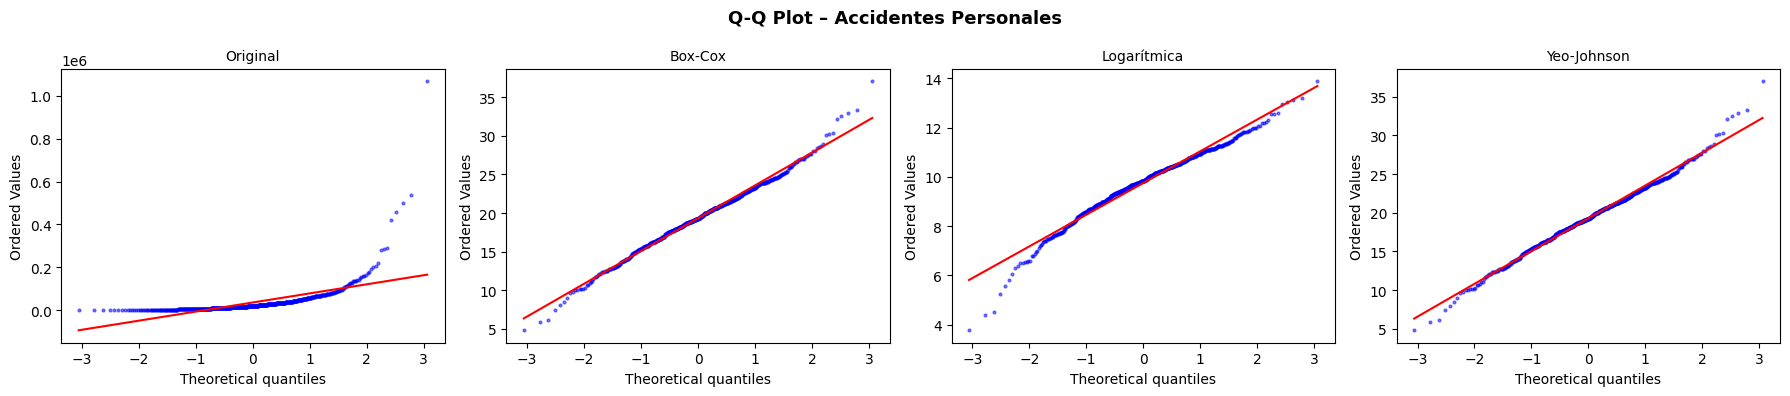

  PRUEBA DE NORMALIDAD – GMM
  (Shapiro-Wilk, muestra aleatoria n=500)
Transformación        Estadístico        p-valor  ¿Normal α=0.05?
-----------------------------------------------------------------
Original                 0.534081       0.000000               NO
Box-Cox                  0.997914       0.802811               SÍ
Logarítmica              0.988886       0.000762               NO
Yeo-Johnson              0.990609       0.002845               NO


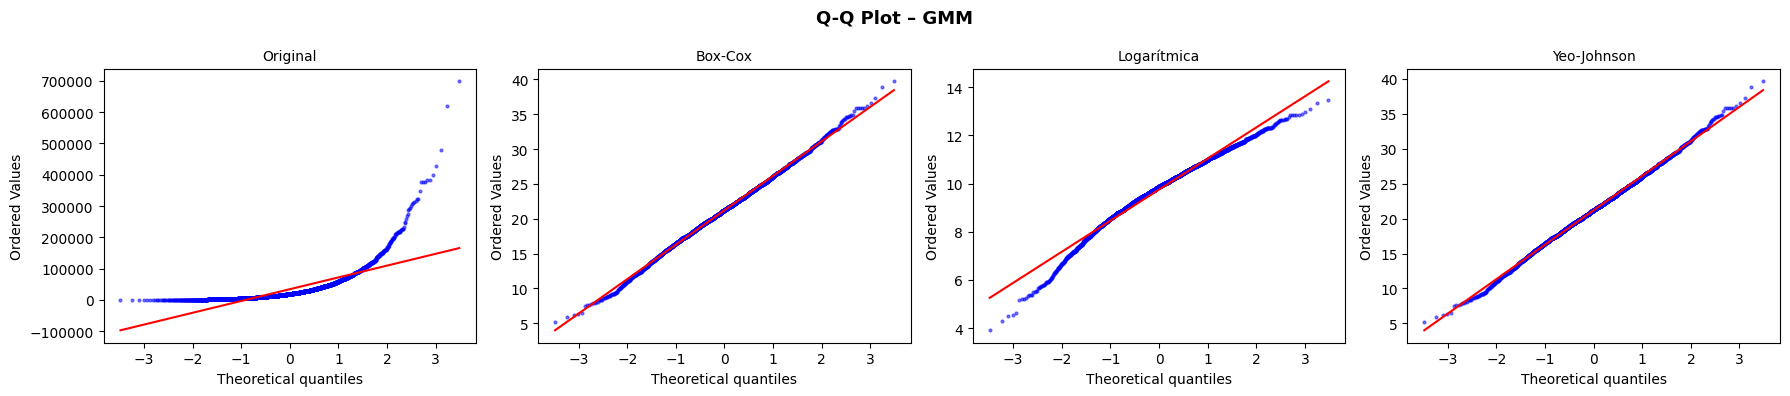


CONCLUSIONES DEL Q-Q PLOT Y PRUEBA DE NORMALIDAD
La original se ve una desviación de la normalidad pues los puntos del Q-Q se alejan de la línea diagonal.
En Box-Cox y Logarítmica se acercan a la normal cuando los datos son positivos.
Y en Yeo-Johnson, como es más flexible porque acepta ceros y valores negativos,
entonces es similar al de Box-Cox en este caso (todos los montos > 0).

Ahora, si el p-valor de Shapiro-Wilk > 0.05 no rechazamos normalidad.



In [112]:
# PUNTO 6

# Q-Q Plot

# Para que los resultados de Shapiro siempre sean iguales
np.random.seed(42)

for ramo in ['Accidentes Personales', 'GMM']:
    d = df[(df['ramo'] == ramo) & (df['monto_pagado'] > 0)]['monto_pagado'].dropna()

    bc_data, lambda_bc = boxcox(d)
    log_data = np.log1p(d).values
    yj_data, lambda_yj = yeojohnson(d)

    series = {
        'Original'     : d.values,
        'Box-Cox'      : bc_data,
        'Logarítmica'  : log_data,
        'Yeo-Johnson'  : yj_data,
    }

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'Q-Q Plot – {ramo}', fontsize=13, fontweight='bold')

    print(f'  PRUEBA DE NORMALIDAD – {ramo}')
    print(f'  (Shapiro-Wilk, muestra aleatoria n=500)')
    print(f'{"Transformación":<18} {"Estadístico":>14} {"p-valor":>14} {"¿Normal α=0.05?":>16}')
    print('-' * 65)

    for ax, (titulo, vals) in zip(axes, series.items()):
        stats.probplot(vals, dist='norm', plot=ax)
        ax.set_title(titulo, fontsize=10)
        ax.get_lines()[0].set(markersize=2, alpha=0.5)

        # Shapiro-Wilk con muestra de 500 (límite del test)
        muestra = np.random.choice(vals, size=min(500, len(vals)), replace=False)
        stat, p = shapiro(muestra)
        normal = 'SÍ' if p > 0.05 else 'NO'
        print(f'{titulo:<18} {stat:>14.6f} {p:>14.6f} {normal:>16}')

    plt.tight_layout()
    plt.show()

print("""
CONCLUSIONES DEL Q-Q PLOT Y PRUEBA DE NORMALIDAD
La original se ve una desviación de la normalidad pues los puntos del Q-Q se alejan de la línea diagonal.
En Box-Cox y Logarítmica se acercan a la normal cuando los datos son positivos.
Y en Yeo-Johnson, como es más flexible porque acepta ceros y valores negativos,
entonces es similar al de Box-Cox en este caso (todos los montos > 0).

Ahora, si el p-valor de Shapiro-Wilk > 0.05 no rechazamos normalidad.
""")


VARIABLE DERIVADA: MAYOR DE 65 AÑOS
Accidentes Personales    :     37 pólizas (0.71%)
GMM                      :    161 pólizas (0.71%)

VARIABLE DERIVADA: SINIESTROS ALTOS

Accidentes Personales
Umbral considerado: $25,000
Total de siniestros        : 1,833
Siniestros altos          : 263
% del total de siniestros : 14.35%

GMM
Umbral considerado: $200,000
Total de siniestros        : 8,146
Siniestros altos          : 45
% del total de siniestros : 0.55%


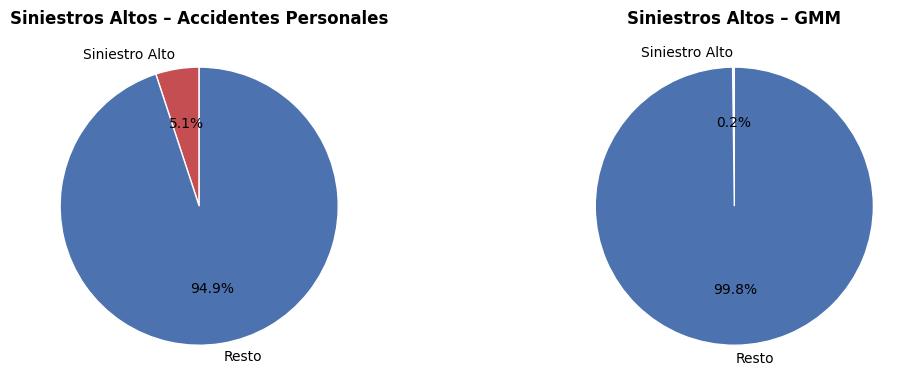

In [121]:
# PUNTO 7

###### Variables Derivadas

# Mayor de 65 años
df['mayor_65'] = (df['edad'] > 65).astype(int)

# Siniestros altos
umbral_ap  = 25_000
umbral_gmm = 200_000

df['siniestro_alto'] = 0

mask_ap_alto = (
    (df['ramo'] == 'Accidentes Personales') &
    (df['monto_pagado'] > umbral_ap)
)

mask_gmm_alto = (
    (df['ramo'] == 'GMM') &
    (df['monto_pagado'] > umbral_gmm)
)

df.loc[mask_ap_alto | mask_gmm_alto, 'siniestro_alto'] = 1

# ─────────────────────────────────────────────────────────────
# MAYORES DE 65 AÑOS
# ─────────────────────────────────────────────────────────────

print('=' * 70)
print('VARIABLE DERIVADA: MAYOR DE 65 AÑOS')
print('=' * 70)

for ramo in ['Accidentes Personales', 'GMM']:
    d = df[df['ramo'] == ramo]

    n_mayor65 = d['mayor_65'].sum()
    pct_mayor65 = n_mayor65 / len(d) * 100

    print(f'{ramo:<25}: {n_mayor65:>6,} pólizas ({pct_mayor65:.2f}%)')

# ─────────────────────────────────────────────────────────────
# SINIESTROS ALTOS
# ─────────────────────────────────────────────────────────────

print('\n' + '=' * 70)
print('VARIABLE DERIVADA: SINIESTROS ALTOS')
print('=' * 70)

for ramo, umbral in [
    ('Accidentes Personales', umbral_ap),
    ('GMM', umbral_gmm)
]:

    d = df[df['ramo'] == ramo]

    # Pólizas con siniestro alto
    n_altos = d['siniestro_alto'].sum()

    # Total de siniestros reportados
    total_siniestros = d['n_siniestros'].sum()

    pct_siniestros = (
        n_altos / total_siniestros * 100
        if total_siniestros > 0 else 0
    )

    print(f'\n{ramo}')
    print(f'Umbral considerado: ${umbral:,.0f}')
    print(f'Total de siniestros        : {total_siniestros:,.0f}')
    print(f'Siniestros altos          : {n_altos:,.0f}')
    print(f'% del total de siniestros : {pct_siniestros:.2f}%')

# ─────────────────────────────────────────────────────────────
# VISUALIZACIÓN
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ramo in zip(axes, ['Accidentes Personales', 'GMM']):

    d = df[df['ramo'] == ramo]

    altos = d['siniestro_alto'].sum()
    normales = len(d) - altos

    ax.pie(
        [altos, normales],
        labels=['Siniestro Alto', 'Resto'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#C44E52', '#4C72B0'],
        wedgeprops={'edgecolor': 'white'}
    )

    ax.set_title(
        f'Siniestros Altos – {ramo}',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
# PUNTO 8

# Calcula la media del siniestro por sexo, año de inicio de vigencia y plan.


